In [20]:
import h5py
import numpy as np
import pandas as pd
import random
import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import corner

from scipy import stats
from astroML.utils import completeness_contamination
from astroML.classification import GMMBayes

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, 
    recall_score, 
    precision_score, 
    roc_curve, 
    roc_auc_score, 
    auc, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)
import tensorflow
from tensorflow import keras

Can a computern learn if we're going to detect a GW?

In [21]:
with h5py.File('sample_2e7_design_precessing_higherordermodes_3detectors.h5', 'r') as file:
    
    keys = list(file.keys())
    print(keys)
    
    data = {}
    for key in keys:
        data[key] = file[key][:]

total_samples = len(data['det'])
print (f"Total samples:{total_samples}")

['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'det', 'iota', 'mtot', 'psi', 'q', 'ra', 'snr', 'z']
Total samples:20000000


In [22]:
# Perform downsampling to 10% of the data to perform the first tests
N_samples = total_samples // 10

idx = np.random.choice(total_samples, N_samples, replace=False)

par_keys = ['mtot', 'q', 'chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'ra', 'iota', 'psi', 'z'] # remove snr
lab_keys = ['det']

# Create X and y 
X = np.stack([data[k][idx] for k in par_keys], axis=1)
y = data['det'][idx].astype(int)

# Split between train and test
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=52)

# Split between train and validation

X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=52)


# Rescale the data
X_mean = X_train.mean(axis=0, keepdims=True)
X_std = X_train.std(axis=0, keepdims=True) + 1e-7
X_train = (X_train - X_mean) / X_std
X_val = (X_val - X_mean) / X_std
X_test= (X_test - X_mean) / X_std


print(len(X_train))
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)


1280000
(1280000, 13)
(320000, 13)
(400000, 13)


In [23]:
keras.backend.clear_session() # Make sure that we are starting a new model and not adding to an earlier one
np.random.seed(42) # Set the numpy and tensorflow random seeds so that we all get the same answer
tensorflow.random.set_seed(42)

In [24]:
# Create a first MLP model
model = keras.models.Sequential([
   keras.layers.InputLayer(input_shape=[X_train.shape[1]]), 
    keras.layers.Dense(units=64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(units=32, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(units=1, activation='sigmoid')
])

print(model.summary())

/Users/tommasogrisetti/Desktop/università/Magistrale/Astrostatistic and Machine Learning/astrostatistics_bicocca_2025-main/.venv/lib/python3.11/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

None


In [25]:
# For binary classification, we use 'binary_crossentropy'
model.compile(
    loss="binary_crossentropy", 
    optimizer="adam", 
    metrics=[keras.metrics.Precision(name='precision'),
        keras.metrics.AUC(curve='PR', name='pr_auc')]
)

In [26]:
# Train the model
clf = model.fit(
    X_train, y_train, 
    epochs=20,
    validation_data=(X_val, y_val)
)

Epoch 1/20
40000/40000 ━━━━━━━━━━━━━━━━━━━━ 53s 1ms/step - loss: 0.0899 - pr_auc: 0.9447 - precision: 0.8752 - val_loss: 0.0667 - val_pr_auc: 0.9709 - val_precision: 0.9169
Epoch 2/20
40000/40000 ━━━━━━━━━━━━━━━━━━━━ 52s 1ms/step - loss: 0.0755 - pr_auc: 0.9602 - precision: 0.8953 - val_loss: 0.0639 - val_pr_auc: 0.9741 - val_precision: 0.9222
Epoch 3/20
40000/40000 ━━━━━━━━━━━━━━━━━━━━ 52s 1ms/step - loss: 0.0720 - pr_auc: 0.9634 - precision: 0.8996 - val_loss: 0.0598 - val_pr_auc: 0.9774 - val_precision: 0.9170
Epoch 4/20
40000/40000 ━━━━━━━━━━━━━━━━━━━━ 52s 1ms/step - loss: 0.0695 - pr_auc: 0.9659 - precision: 0.9038 - val_loss: 0.0566 - val_pr_auc: 0.9801 - val_precision: 0.9252
Epoch 5/20
40000/40000 ━━━━━━━━━━━━━━━━━━━━ 52s 1ms/step - loss: 0.0675 - pr_auc: 0.9676 - precision: 0.9078 - val_loss: 0.0555 - val_pr_auc: 0.9805 - val_precision: 0.9333
Epoch 6/20
40000/40000 ━━━━━━━━━━━━━━━━━━━━ 52s 1ms/step - loss: 0.0661 - pr_auc: 0.9689 - precision: 0.9091 - val_loss: 0.0547 - val_p

In [27]:
# Start with the prediction of 10 sample from test set

idx10 = np.random.choice(np.arange(len(y_test)), size=10, replace=False)
X_new = X_test[idx10]
y_true_10 = y_test[idx10]

# Prediction
y_proba_10 = model.predict(X_new, verbose=0).flatten()
y_pred_10 = (y_proba_10 > 0.5).astype(int)

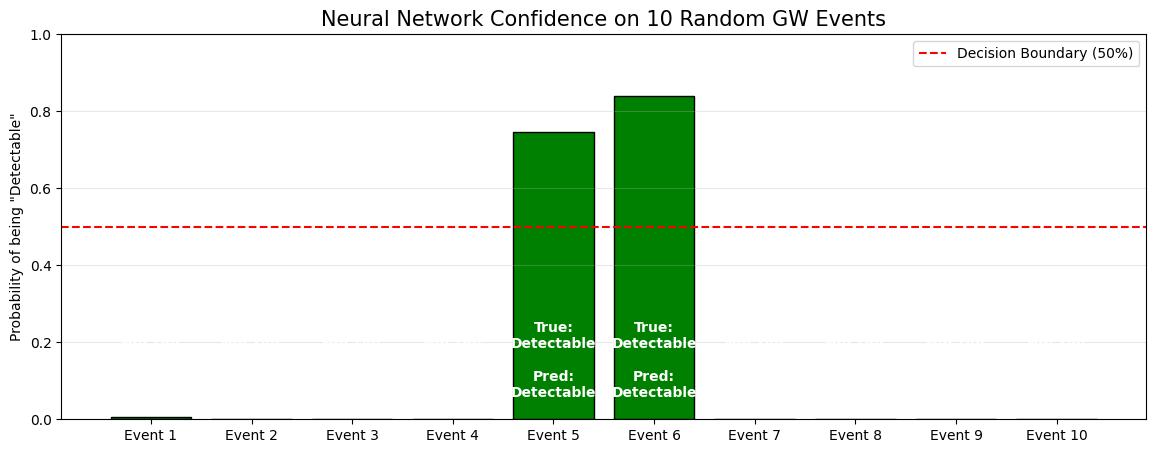

In [28]:
# Plot result for the 10 sample
gw_labels = {0: "Not Det", 1: "Detectable"}

plt.figure(figsize=(14, 5))

# Colorbars: Green if the prediction matches reality, Red if it's an error
colors = ['green' if true == pred else 'red' 
          for true, pred in zip(y_true_10, y_pred_10)]

bars = plt.bar(range(10), y_proba_10, color=colors, edgecolor='black')
plt.axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='Decision Boundary (50%)')

for i, bar in enumerate(bars):
    actual = gw_labels[y_true_10[i]]
    pred = gw_labels[y_pred_10[i]]
    plt.text(bar.get_x() + bar.get_width()/2, 0.05, 
             f"True:\n{actual}\n\nPred:\n{pred}", 
             ha='center', va='bottom', color='white', fontweight='bold', fontsize=10)

plt.title('Neural Network Confidence on 10 Random GW Events', fontsize=15)
plt.ylabel('Probability of being "Detectable"')
plt.xticks(range(10), [f"Event {i+1}" for i in range(10)])
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [29]:
# Predict for all test set
# Prediction
y_proba = model.predict(X_test, verbose=0).flatten()
y_pred = (y_proba > 0.5).astype(int)


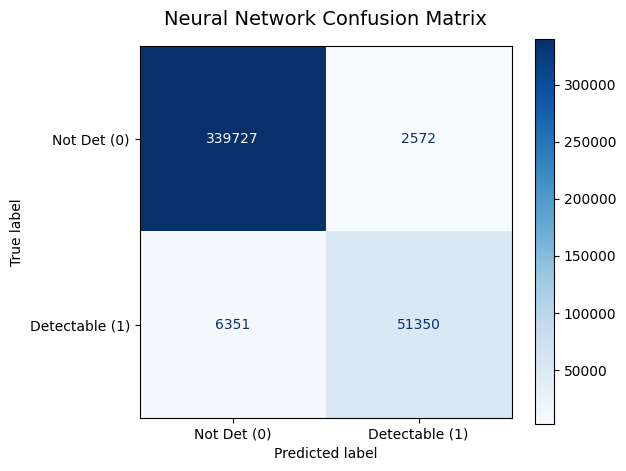

In [30]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Plot it using the Scikit-Learn display tool you imported
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=["Not Det (0)", "Detectable (1)"]
)

# We use a blue color map, and 'd' ensures the numbers print as standard integers
disp.plot(cmap="Blues", values_format="d", ax=plt.gca()) 
plt.title("Neural Network Confusion Matrix", fontsize=14, pad=15)
plt.show()


In [ ]:
# Try to improve neural network with hyperparameter tuning
# Start by uning different combination of layers and unit

architectures = [
    [32, 16],          
    [64, 32],          
    [128, 64, 32],     
    [256, 128, 64]     
]

results = {}

for config in architectures:
    model_name = " -> ".join(map(str, config))
    print(f"\nTraining Model: {model_name}")
    
    keras.backend.clear_session()
    
    model = keras.models.Sequential()
    model.add(keras.layers.InputLayer(input_shape=[X_train.shape[1]]))
    
    for units in config:
        model.add(keras.layers.Dense(units, activation='relu'))
        model.add(keras.layers.Dropout(0.3))
    
    model.add(keras.layers.Dense(1, activation='sigmoid'))
    
    model.compile(
        loss="binary_crossentropy", 
        optimizer="adam", 
        metrics=[keras.metrics.AUC(curve='PR', name='pr_auc')]
    )
    
    # Train 
    history = model.fit(
        X_train, y_train, 
        epochs=10, 
        validation_data=(X_val, y_val), 
        verbose=0
    )
    
    # Extract the correct key from the history object
    val_pr_auc = max(history.history['val_pr_auc'])
    results[model_name] = val_pr_auc
    print(f"Max Validation PR-AUC: {val_pr_auc:.4f}")

# Find the best configuration
best_config = max(results, key=results.get)
print(f"\nWINNER: {best_config} with {results[best_config]:.4f} PR-AUC")




Training Model: 32 -> 16


/Users/tommasogrisetti/Desktop/università/Magistrale/Astrostatistic and Machine Learning/astrostatistics_bicocca_2025-main/.venv/lib/python3.11/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Max Validation PR-AUC: 0.9693

Training Model: 64 -> 32
Max Validation PR-AUC: 0.9780

Training Model: 128 -> 64 -> 32
Max Validation PR-AUC: 0.9863

Training Model: 256 -> 128 -> 64


In [ ]:
# Try to modify droprate on the best model
dropout_rates_to_test = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

results = {}

print("Testing Dropout Rates on the [256 -> 128 -> 64] Architecture\n")

for rate in dropout_rates_to_test:
    keras.backend.clear_session()
    np.random.seed(42)
    tensorflow.random.set_seed(42)
    
    model = keras.models.Sequential([
        keras.layers.InputLayer(input_shape=[X_train.shape[1]]), 
        
        keras.layers.Dense(units=256, activation='relu'),
        keras.layers.Dropout(rate),                         
        
        keras.layers.Dense(units=128, activation='relu'),
        keras.layers.Dropout(rate),                          
        
        keras.layers.Dense(units=64, activation='relu'),
        keras.layers.Dropout(rate),                           
      
        keras.layers.Dense(units=1, activation='sigmoid')
    ])
    
    model.compile(
        loss="binary_crossentropy", 
        optimizer="adam", 
        metrics=[keras.metrics.AUC(curve='PR', name='pr_auc')]
    )
    
    history = model.fit(
        X_train, y_train, 
        epochs=20, 
        validation_data=(X_val, y_val), 
        verbose=0
    )
    
    # Extract PR-AUC results
    max_val_pr_auc = max(history.history['val_pr_auc'])
    final_train_pr_auc = history.history['pr_auc'][-1]
    
    results[rate] = max_val_pr_auc
    print(f"Dropout: {rate:.1f} | Train PR-AUC: {final_train_pr_auc:.4f} | Max Val PR-AUC: {max_val_pr_auc:.4f}")

best_rate = max(results, key=results.get)
print(f"\nBest dropout Rate of {best_rate} with {results[best_rate]:.4f} Val PR-AUC")

Testing Dropout Rates on the [256 -> 128 -> 64] Architecture

Dropout: 0.1 | Train PR-AUC: 0.9883 | Max Val PR-AUC: 0.9536
Dropout: 0.2 | Train PR-AUC: 0.9785 | Max Val PR-AUC: 0.9533
Dropout: 0.3 | Train PR-AUC: 0.9706 | Max Val PR-AUC: 0.9593
Dropout: 0.4 | Train PR-AUC: 0.9618 | Max Val PR-AUC: 0.9576
Dropout: 0.5 | Train PR-AUC: 0.9495 | Max Val PR-AUC: 0.9602
Dropout: 0.6 | Train PR-AUC: 0.9412 | Max Val PR-AUC: 0.9536

Best dropout Rate of 0.5 with 0.9602 Val PR-AUC


In [ ]:
#Try to modify the learning rates

learning_rates_to_test = [0.01, 0.001, 0.0001, 0.00001]

best_dropout = best_rate # using the previous best dropout rate

results = {}

print("Testing Learning Rates on the Adam Optimizer\n")

for lr in learning_rates_to_test:
    keras.backend.clear_session()
    np.random.seed(42)
    tensorflow.random.set_seed(42)
    
    model = keras.models.Sequential([
        keras.layers.InputLayer(input_shape=[X_train.shape[1]]), 
        
        keras.layers.Dense(units=256, activation='relu'),
        keras.layers.Dropout(best_dropout),
        
        keras.layers.Dense(units=128, activation='relu'),
        keras.layers.Dropout(best_dropout),
        
        keras.layers.Dense(units=64, activation='relu'),
        keras.layers.Dropout(best_dropout),
        
        keras.layers.Dense(units=1, activation='sigmoid')
    ])
    

    custom_adam = keras.optimizers.Adam(learning_rate=lr)
    model.compile(
        loss="binary_crossentropy", 
        optimizer=custom_adam, 
        metrics=[keras.metrics.AUC(curve='PR', name='pr_auc')]
    )

    # Increase epochs slightly for lower learning rates to allow them to converge
    history = model.fit(X_train, y_train, epochs=30, validation_data=(X_val, y_val), verbose=0)
    
    max_val_pr_auc = max(history.history['val_pr_auc'])
    final_train_pr_auc = history.history['pr_auc'][-1]
    
    results[lr] = max_val_pr_auc

    print(f"LR: {lr:.5f} | Train PR-AUC: {final_train_pr_auc:.4f} | Max Val PR-AUC: {max_val_pr_auc:.4f}")

best_lr = max(results, key=results.get)
print(f"\nBest learning Rate of {best_lr} with {results[best_lr]:.4f} Val PR-AUC")

Testing Learning Rates on the Adam Optimizer

LR: 0.01000 | Train PR-AUC: 0.7640 | Max Val PR-AUC: 0.9321
LR: 0.00100 | Train PR-AUC: 0.9571 | Max Val PR-AUC: 0.9621
LR: 0.00010 | Train PR-AUC: 0.8808 | Max Val PR-AUC: 0.9263
LR: 0.00001 | Train PR-AUC: 0.5856 | Max Val PR-AUC: 0.7849

Best learning Rate of 0.001 with 0.9621 Val PR-AUC


In [ ]:
# print the confusion matrix for the best parameter combination

keras.backend.clear_session()
np.random.seed(42)
tensorflow.random.set_seed(42)

best_model = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=[X_train.shape[1]]), 
    keras.layers.Dense(units=256, activation='relu'),
    keras.layers.Dropout(best_dropout),
    keras.layers.Dense(units=128, activation='relu'),
    keras.layers.Dropout(best_dropout),
    keras.layers.Dense(units=64, activation='relu'),
    keras.layers.Dropout(best_dropout),
    keras.layers.Dense(units=1, activation='sigmoid')
])

custom_adam = keras.optimizers.Adam(learning_rate=best_lr)

# FIX: Keep PR-AUC here so you can monitor the "purity" of the training in the logs
best_model.compile(
    loss="binary_crossentropy", 
    optimizer=custom_adam, 
    metrics=["accuracy", keras.metrics.AUC(curve='PR', name='pr_auc')]
)

# Training with verbose=1 to see the final convergence
history = best_model.fit(X_train, y_train, epochs=30, validation_data=(X_val, y_val), verbose=1)

# Get probabilities and default predictions (0.5 threshold)
y_proba_final = best_model.predict(X_test, verbose=0).flatten()
y_pred_final = (y_proba_final > 0.5).astype(int)


Epoch 1/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8863 - loss: 0.2505 - pr_auc: 0.5948 - val_accuracy: 0.9281 - val_loss: 0.1603 - val_pr_auc: 0.8826
Epoch 2/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9218 - loss: 0.1689 - pr_auc: 0.7736 - val_accuracy: 0.9413 - val_loss: 0.1301 - val_pr_auc: 0.9103
Epoch 3/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9340 - loss: 0.1466 - pr_auc: 0.8396 - val_accuracy: 0.9456 - val_loss: 0.1145 - val_pr_auc: 0.9184
Epoch 4/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9430 - loss: 0.1352 - pr_auc: 0.8637 - val_accuracy: 0.9494 - val_loss: 0.1094 - val_pr_auc: 0.9253
Epoch 5/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9468 - loss: 0.1239 - pr_auc: 0.8883 - val_accuracy: 0.9494 - val_loss: 0.1054 - val_pr_auc: 0.9306
Epoch 6/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9500 - loss: 0.1169 - pr_auc: 0.9000 - val_accuracy: 0.9538 - val_loss: 0.0978 - val_pr_auc: 0.9361
Epoc

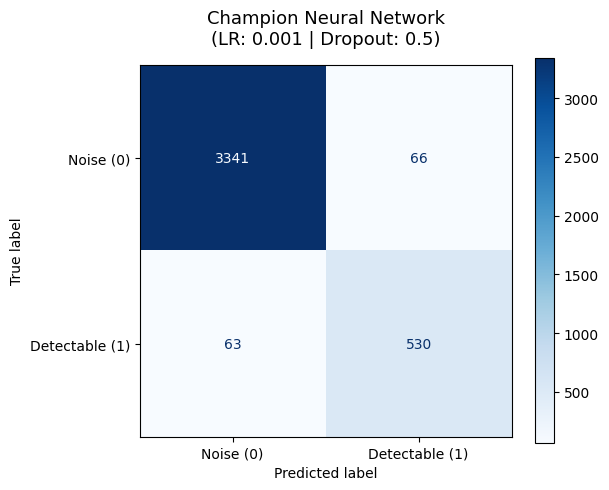

In [ ]:
# Plot matrix
cm_best = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best, 
    display_labels=["Noise (0)", "Detectable (1)"]
)

disp.plot(cmap="Blues", values_format="d", ax=plt.gca()) 
plt.title(f"Champion Neural Network\n(LR: {best_lr} | Dropout: {best_dropout})", fontsize=13, pad=15)
plt.grid(False) # Ensure the grid doesn't overlap the matrix
plt.show()

In [ ]:
# Implement autoencoder

# Filter train and val to only include noise (label 0)
X_train_noise = X_train[y_train == 0]
X_val_noise = X_val[y_val == 0]

keras.backend.clear_session()
np.random.seed(42)
tensorflow.random.set_seed(42)

# Build the Autoencoder (Bottleneck architecture)

encoder_input = keras.layers.Input(shape=[X_train.shape[1]])
x = keras.layers.Dense(units=8, activation='relu')(encoder_input)
x = keras.layers.Dense(units=4, activation='relu')(x)
bottleneck = keras.layers.Dense(units=2, activation='linear')(x) # Latent space

x = keras.layers.Dense(units=4, activation='relu')(bottleneck)
x = keras.layers.Dense(units=8, activation='relu')(x)
decoder_output = keras.layers.Dense(units=X_train.shape[1], activation='linear')(x)

autoencoder = keras.models.Model(inputs=encoder_input, outputs=decoder_output)

autoencoder.compile(
    loss="mse", 
    optimizer=keras.optimizers.Adam(learning_rate=0.001)
)

history = autoencoder.fit(
    X_train_noise, X_train_noise, 
    epochs=20,
    batch_size=32,
    validation_data=(X_val_noise, X_val_noise), # Validate only on noise
    verbose=1
)

Epoch 1/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9302 - val_loss: 0.8628
Epoch 2/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8405 - val_loss: 0.8322
Epoch 3/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8252 - val_loss: 0.8229
Epoch 4/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8175 - val_loss: 0.8169
Epoch 5/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8122 - val_loss: 0.8121
Epoch 6/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8077 - val_loss: 0.8081
Epoch 7/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8037 - val_loss: 0.8047
Epoch 8/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7999 - val_loss: 0.8010
Epoch 9/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7967 - val_loss: 0.7977
Epoch 10/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7935 - val_loss: 0.7951
Epoch 11/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7910 - val_loss: 0.7926
Epoch 12/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Locked Threshold (from Validation): 1.4094


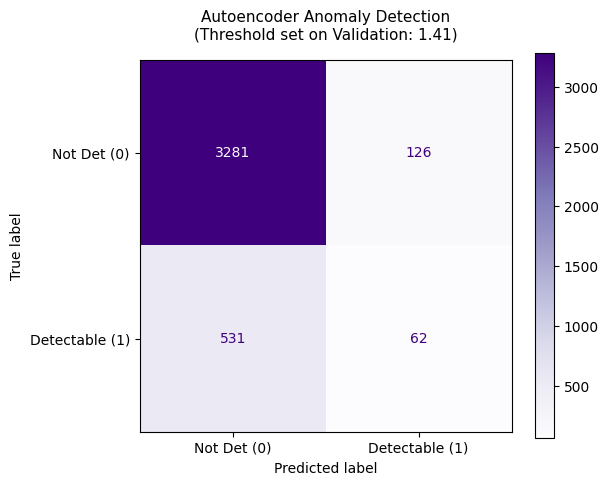

Autoencoder Accuracy: 0.8357
Autoencoder Precision: 0.3298
Autoencoder Recall (Completeness): 0.1046


In [ ]:
# Calculate MSE on the VALIDATION SET to find the threshold
val_reconstructions = autoencoder.predict(X_val, verbose=0)
val_mse = np.mean(np.power(X_val - val_reconstructions, 2), axis=1)

# Set threshold based on Validation noise. 
# For high precision, we want a threshold that noise rarely exceeds.
# Let's use the 95th or 98th percentile of VALIDATION errors.
threshold = np.percentile(val_mse, 95) 
print(f"Locked Threshold (from Validation): {threshold:.4f}")

# Now apply this LOCKED threshold to the TEST SET
reconstructions = autoencoder.predict(X_test, verbose=0)
test_mse = np.mean(np.power(X_test - reconstructions, 2), axis=1)

y_pred_autoencoder = (test_mse > threshold).astype(int)

# Plotting
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_autoencoder)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=["Not Det (0)", "Detectable (1)"]
)

disp.plot(cmap="Purples", values_format="d", ax=plt.gca()) 
plt.title(f"Autoencoder Anomaly Detection\n(Threshold set on Validation: {threshold:.2f})", fontsize=11, pad=15)
plt.grid(False)
plt.show()

# Metrics
print(f"Autoencoder Accuracy: {accuracy_score(y_test, y_pred_autoencoder):.4f}")
print(f"Autoencoder Precision: {precision_score(y_test, y_pred_autoencoder):.4f}")
print(f"Autoencoder Recall (Completeness): {recall_score(y_test, y_pred_autoencoder):.4f}")

In [ ]:


# Test the different number of parameters in the bottleneck
bottleneck_sizes = [2, 4, 6]
results = {}

print("Optimizing Bottleneck Size using Average Precision (PR-AUC)\n")

for size in bottleneck_sizes:
    keras.backend.clear_session()
    np.random.seed(42)
    tensorflow.random.set_seed(42)
    
    # 1. Build Model
    encoder_input = keras.layers.Input(shape=[X_train.shape[1]])
    x = keras.layers.Dense(units=8, activation='relu')(encoder_input)
    bottleneck = keras.layers.Dense(units=size, activation='linear')(x) 
    
    x = keras.layers.Dense(units=8, activation='relu')(bottleneck)
    decoder_output = keras.layers.Dense(units=X_train.shape[1], activation='linear')(x)
    
    autoencoder = keras.models.Model(inputs=encoder_input, outputs=decoder_output)
    autoencoder.compile(loss="mse", optimizer=keras.optimizers.Adam(learning_rate=0.001))
    
    # 2. Fit ONLY on noise data
    # Use the filtered variables we created earlier
    autoencoder.fit(
        X_train_noise, X_train_noise, 
        epochs=20, 
        batch_size=32, 
        validation_data=(X_val_noise, X_val_noise), 
        verbose=0
    )
    
    # 3. Evaluate on the FULL validation set (Noise + Signals)
    val_reconstructions = autoencoder.predict(X_val, verbose=0)
    val_mse = np.mean(np.power(X_val - val_reconstructions, 2), axis=1)
    
    # Use Average Precision (PR-AUC) instead of ROC-AUC
    ap_score = average_precision_score(y_val, val_mse)
    
    results[size] = ap_score
    print(f"Bottleneck: {size} | Average Precision (PR-AUC): {ap_score:.4f}")

# Declare the winner
best_bottleneck = max(results, key=results.get)
print(f"\nWINNER: Bottleneck size {best_bottleneck} with {results[best_bottleneck]:.4f} PR-AUC")

Optimizing Bottleneck Size using Average Precision (PR-AUC)



NameError: name 'average_precision_score' is not defined

In [ ]:
from sklearn.metrics import precision_recall_curve

# --- 1. Rebuild and Train Champion Autoencoder ---
keras.backend.clear_session()
np.random.seed(42)
tensorflow.random.set_seed(42)

encoder_input = keras.layers.Input(shape=[X_train.shape[1]])
x = keras.layers.Dense(units=8, activation='relu')(encoder_input)
# Use the best_bottleneck found in the previous loop
bottleneck = keras.layers.Dense(units=best_bottleneck, activation='linear')(x) 
x = keras.layers.Dense(units=8, activation='relu')(bottleneck)
decoder_output = keras.layers.Dense(units=X_train.shape[1], activation='linear')(x)

champion_auto = keras.models.Model(inputs=encoder_input, outputs=decoder_output)
champion_auto.compile(loss="mse", optimizer=keras.optimizers.Adam(learning_rate=0.001))

# FIT ONLY ON NOISE
champion_auto.fit(
    X_train_noise, X_train_noise, 
    epochs=20, 
    batch_size=32, 
    validation_data=(X_val_noise, X_val_noise), 
    verbose=1
)

# --- 2. Calculate optimal Threshold from Validation Set (Precision-Focused) ---
print("\nFinding optimal threshold from Validation Set...")
val_reconstructions = champion_auto.predict(X_val, verbose=0)
val_mse = np.mean(np.power(X_val - val_reconstructions, 2), axis=1)

# Get Precision-Recall values for MSE as a score
precisions, recalls, thresholds_pr = precision_recall_curve(y_val, val_mse)

# We want high precision (e.g., 0.90) to avoid false alerts
target_precision = 0.90
# Find the threshold where precision first hits our target
idx = np.where(precisions >= target_precision)[0][0]
locked_threshold = thresholds_pr[idx]

print(f"Locked Threshold for {target_precision*100}% Precision: {locked_threshold:.4f}")

# --- 3. Evaluate on the Test Set ---
print("\nEvaluating Champion Autoencoder on the Test Set...")
test_reconstructions = champion_auto.predict(X_test, verbose=0)
test_mse = np.mean(np.power(X_test - test_reconstructions, 2), axis=1)

# Final binary prediction
y_pred_final = (test_mse > locked_threshold).astype(int)

# --- 4. Plotting ---
cm_best_auto = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best_auto, 
    display_labels=["Noise (0)", "Detectable (1)"]
)
disp.plot(cmap="Purples", values_format="d", ax=plt.gca()) 
plt.title(f"Best Autoencoder (Bottleneck: {best_bottleneck})\nThreshold tuned for {target_precision*100}% Precision", fontsize=10)
plt.grid(False)
plt.show()

# Final Metrics
print(f"Final Test Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Final Test Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"Final Test Recall: {recall_score(y_test, y_pred_final):.4f}")

Epoch 1/20
34236/34236 ━━━━━━━━━━━━━━━━━━━━ 38s 1ms/step - loss: 0.5245 - val_loss: 0.5418
Epoch 2/20
34236/34236 ━━━━━━━━━━━━━━━━━━━━ 37s 1ms/step - loss: 0.5159 - val_loss: 0.5420
Epoch 3/20
34236/34236 ━━━━━━━━━━━━━━━━━━━━ 37s 1ms/step - loss: 0.5156 - val_loss: 0.5420
Epoch 4/20
34236/34236 ━━━━━━━━━━━━━━━━━━━━ 37s 1ms/step - loss: 0.5154 - val_loss: 0.5420
Epoch 5/20
34236/34236 ━━━━━━━━━━━━━━━━━━━━ 37s 1ms/step - loss: 0.5153 - val_loss: 0.5419
Epoch 6/20
34236/34236 ━━━━━━━━━━━━━━━━━━━━ 37s 1ms/step - loss: 0.5152 - val_loss: 0.5419
Epoch 7/20
34236/34236 ━━━━━━━━━━━━━━━━━━━━ 37s 1ms/step - loss: 0.5151 - val_loss: 0.5419
Epoch 8/20
34236/34236 ━━━━━━━━━━━━━━━━━━━━ 37s 1ms/step - loss: 0.5151 - val_loss: 0.5418
Epoch 9/20
34236/34236 ━━━━━━━━━━━━━━━━━━━━ 38s 1ms/step - loss: 0.5150 - val_loss: 0.5418
Epoch 10/20
34236/34236 ━━━━━━━━━━━━━━━━━━━━ 37s 1ms/step - loss: 0.5149 - val_loss: 0.5418
Epoch 11/20
34236/34236 ━━━━━━━━━━━━━━━━━━━━ 37s 1ms/step - loss: 0.5149 - val_loss: 0.54

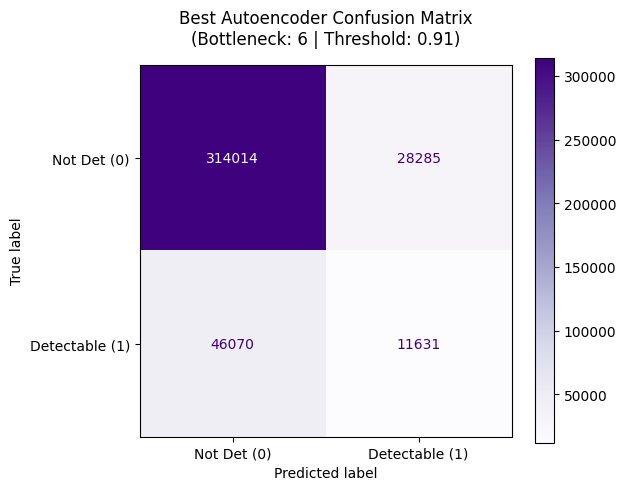

Final Test Accuracy: 0.8141
Final Test Completeness (Recall): 0.2016


In [ ]:
# Plot confusion matrix
cm_best_auto = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best_auto, 
    display_labels=["Not Det (0)", "Detectable (1)"]
)

# Use ax=plt.gca() to ensure the title and labels don't overlap
disp.plot(cmap="Purples", values_format="d", ax=plt.gca()) 

# Use the locked_threshold we calculated in the previous step
plt.title(f"Best Autoencoder Confusion Matrix\n(Bottleneck: {best_bottleneck} | Threshold: {locked_threshold:.2f})", 
          fontsize=12, pad=15)
plt.grid(False) # Clean look for the matrix
plt.show()

# Print Final Metrics
final_accuracy = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final)
final_recall = recall_score(y_test, y_pred_final)

print(f"--- Final Autoencoder Performance ---")
print(f"Final Test Accuracy: {final_accuracy:.4f}")
print(f"Final Test Precision (Purity): {final_precision:.4f}")
print(f"Final Test Recall (Completeness): {final_recall:.4f}")